In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler

from sklearn.model_selection import train_test_split

import dlib
import cv2
import face_recognition
import sys

from PIL import UnidentifiedImageError
from PIL import Image

from insightface import app
from tqdm.autonotebook import tqdm as notebook_tqdm

/opt/anaconda3/envs/myenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# The documents presents a small overview of the datasets used in this directory (LWF is used for face detection and pins dataset - for the model training)

## Overview of the csv files of the dataset:
* lfw_allnames.csv: a CSV containing two columns; name (a list of all names in the entire dataset) and images (the number of images available for the each name)
* matchpairsDevTest: a random sample of 500 image pairs featuring the same individual, with columns for the name and the two image labels
* matchpairsDevTrain: a random sample of 1100 image pairs featuring the same individual, with columns for the name and the image labels
* mismatchpairsDevTest: a random sample of 500 image pairs featuring different individuals, with columns for both names and the two image labels
* mismatchpairsDevTrain: a random sample of 1100 image pairs featuring different individuals, with columns for both names and the two image labels
* pairs.csv: 6000 pairs of images, both matched and mismatched. Matched pair rows contain a name and two image files, while unmatched pair * * rows contain a name for each of the images. For further formating, these two sets of rows will be split into matched_pairs and unmatched_pairs data frames
* people.csv: list of names and image counts, identical to lfw_allnames.csv once null values have been removed. Omit from further analysis
* peopleDevTest.csv: 1711 individuals in the dataset designed for testing: columns for celebrity name and image count (zero overlap with peopleDevTrain.csv)
* peopleDevTrain.csv: 4038 individuals in the dataset designed for training: columns for celebrity name and image count (zero overlap with peopleDevTest.csv)

In [2]:
class CustomDataset(Dataset):
    def __init__(self, img_dir, transforms=None):
        """
        Initialize the dataset by loading all image paths and their corresponding labels.
        """
        self.img_dir = img_dir
        self.transforms = transforms
        self.persons = sorted(os.listdir(img_dir))

        # initialize lists to store image paths and labels
        self.labels = []
        self.all_imgs = []

        # define a mapping of each person's folder name to a numerical label
        self.label_map = {person: idx for idx, person in enumerate(self.persons)}

        # iterate over each person's directory and collect images
        for person in self.persons:
            person_image_dir = os.path.join(self.img_dir, person)
            # check if the path is a valid directory
            if os.path.isdir(person_image_dir):
                # iterate over each image in the person's directory
                for image_name in os.listdir(person_image_dir):
                    image_path = os.path.join(person_image_dir, image_name)
                    if os.path.isfile(image_path):
                        # store the image path and corresponding label
                        self.all_imgs.append(image_path)
                        self.labels.append(self.label_map[person])

    def __getitem__(self, idx):
        img_path = self.all_imgs[idx]
        try:
            # open and convert the image to RGB
            img = Image.open(img_path).convert("RGB")
        except UnidentifiedImageError:
            print(f"Error: Could not identify image file {img_path}")
            return None, None

        label = self.labels[idx]

        # apply the transformations (if any) to the image
        if self.transforms:
            img = self.transforms(img)

        return img, label

    def __len__(self):
        return len(self.all_imgs)

In [3]:
# define the root path where the dataset (LFW in this case) is stored
data_dir_path = 'LFW (Labelled Faces in the Wild (LFW) Dataset)'

# lis all files and subdirectories within the main LFW dataset directory
all_files = os.listdir(data_dir_path)
# construct the path to the specific folder containing the actual face images
image_dir = os.path.join(data_dir_path, 'lfw-deepfunneled', 'lfw-deepfunneled')

#create a dataset from the image directory
dataset = CustomDataset(image_dir)

# Create a DataLoader for the entire dataset
data_loader_full = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

dataset_for_splitting = torch.arange(len(dataset))

# create a data_loader with only 100 samples
dataset_sampler = SubsetRandomSampler(dataset_for_splitting, range(100))
data_loader = DataLoader(dataset_sampler, batch_size=1, collate_fn=lambda x: tuple(zip(*x)))

In [4]:
# person's name -> numerical label
dataset.label_map

{'.DS_Store': 0,
 'AJ_Cook': 1,
 'AJ_Lamas': 2,
 'Aaron_Eckhart': 3,
 'Aaron_Guiel': 4,
 'Aaron_Patterson': 5,
 'Aaron_Peirsol': 6,
 'Aaron_Pena': 7,
 'Aaron_Sorkin': 8,
 'Aaron_Tippin': 9,
 'Abba_Eban': 10,
 'Abbas_Kiarostami': 11,
 'Abdel_Aziz_Al-Hakim': 12,
 'Abdel_Madi_Shabneh': 13,
 'Abdel_Nasser_Assidi': 14,
 'Abdoulaye_Wade': 15,
 'Abdul_Majeed_Shobokshi': 16,
 'Abdul_Rahman': 17,
 'Abdulaziz_Kamilov': 18,
 'Abdullah': 19,
 'Abdullah_Ahmad_Badawi': 20,
 'Abdullah_Gul': 21,
 'Abdullah_Nasseef': 22,
 'Abdullah_al-Attiyah': 23,
 'Abdullatif_Sener': 24,
 'Abel_Aguilar': 25,
 'Abel_Pacheco': 26,
 'Abid_Hamid_Mahmud_Al-Tikriti': 27,
 'Abner_Martinez': 28,
 'Abraham_Foxman': 29,
 'Aby_Har-Even': 30,
 'Adam_Ant': 31,
 'Adam_Freier': 32,
 'Adam_Herbert': 33,
 'Adam_Kennedy': 34,
 'Adam_Mair': 35,
 'Adam_Rich': 36,
 'Adam_Sandler': 37,
 'Adam_Scott': 38,
 'Adel_Al-Jubeir': 39,
 'Adelina_Avila': 40,
 'Adisai_Bodharamik': 41,
 'Adolfo_Aguilar_Zinser': 42,
 'Adolfo_Rodriguez_Saa': 43,
 'Adoo

(-0.5, 249.5, 249.5, -0.5)

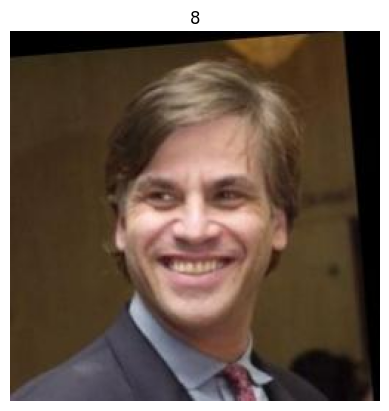

In [5]:
# visalise the image and label
img, label = dataset[10]
plt.title(label)
plt.imshow(img)
plt.axis('off')

In [6]:
cascade_path = 'haarcascade_frontalface_default.xml'
if not os.path.exists(cascade_path):
    print(f"Error: '{cascade_path}' not found. Make sure the file path is correct.")

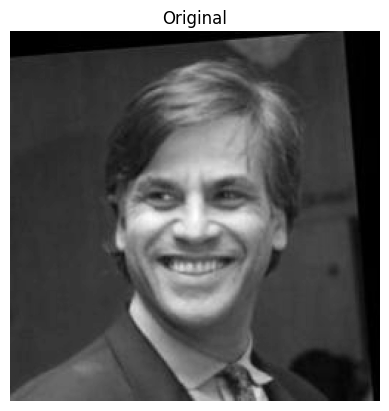

Face detected: [[ 63  63 127 127]]


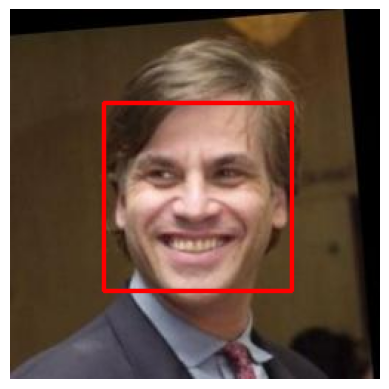

In [7]:
# Apply HAAR cascade
img, label = dataset[10]

img = np.array(img)

gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_image, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()

face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
if face_cascade.empty():
    print("Error: Haar Cascade not loaded. Check the path.")

faces = face_cascade.detectMultiScale(
    gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50)
)


print(f'Face detected: {faces}')
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w ,y+h), (255, 0, 0), 2) # thickness of rectangle = 2.
    
# Display the image with bounding boxes    
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.imshow(img)
plt.axis('off')
plt.show()

8


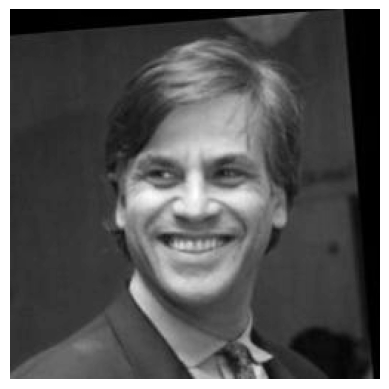

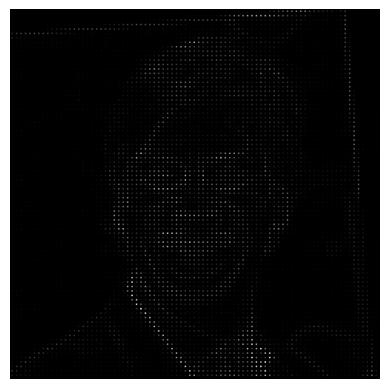

In [8]:
# apply HOG
from skimage.feature import hog
from skimage.transform import resize
from skimage import exposure
import matplotlib.pyplot as plt

img, label = dataset[10]
print(label)
# print(type(img), img.shape)

img = np.array(img)

gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.show()

fd, hog_image = hog(gray_image, orientations=8, pixels_per_cell=(3, 3),
                	cells_per_block=(4, 4), block_norm= 'L2', visualize=True)
plt.axis("off")
plt.imshow(hog_image, cmap="gray")

(-0.5, 159.5, 159.5, -0.5)

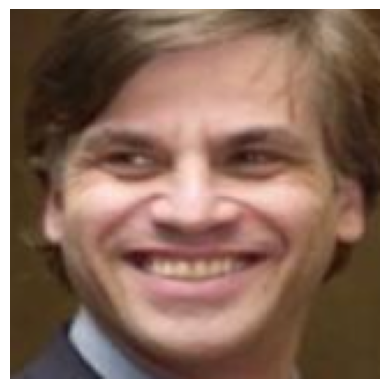

In [9]:
# apply MTCNN
from facenet_pytorch import MTCNN

mtcnn = MTCNN(select_largest=False, margin=40,)

image, label = dataset[10]
plt.imshow(image)

img = np.array(image)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

faces = mtcnn(img_rgb)

if faces is not None:
    faces = faces.permute(1, 2, 0).detach().numpy()
    faces = (faces - faces.min()) / (faces.max() - faces.min())
    
plt.imshow(cv2.cvtColor(faces, cv2.COLOR_BGR2RGB))
plt.axis('off')

/opt/anaconda3/envs/myenv/lib/python3.9/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:69: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
Лицо 1: координаты рамки [ 77.96483  60.28029 177.38298 198.30698], вероятность 0.8290281295776367
[[103.130554 111.84997 ]
 [149.53296  112.86807 ]
 [125.313225 136.63684 ]
 [100.16553  152.33284 ]
 [150.57396  153.32361 ]]


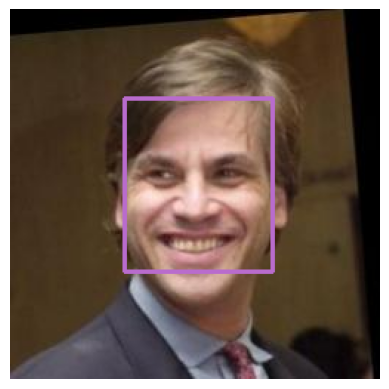

In [10]:
# apply insightface
import insightface
from insightface.app.common import Face
from insightface.model_zoo import model_zoo

det_model_path = 'buffalo_s/det_500m.onnx'
rec_model_path = 'buffalo_s/w600k_mbf.onnx'

det_model = model_zoo.get_model(f'{det_model_path}')
rec_model = model_zoo.get_model(f'{rec_model_path}')

det_model.prepare(ctx_id=0, input_size=(640, 640), det_thres=0.5)

img, label = dataset[10]
img = np.array(img)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

faces = det_model.detect(img_rgb)
bboxes = faces[0]
facemarks = faces[1][0]
# print(bboxes.shape)
for i in range(bboxes.shape[0]):
    bbox = bboxes[i][:4]
    score = bboxes[i][4]
    print(f"Лицо {i+1}: координаты рамки {bbox}, вероятность {score}")
    xmin, ymin, xmax, ymax = bbox
    cv2.rectangle(img=img, pt1=(int(xmin), int(ymin)), pt2=(int(xmax), int(xmax)), color=(185, 108, 205), thickness=2)
plt.imshow(img)
plt.axis('off')
print(facemarks)


faces mmod_rectangles[[(76, 72) (175, 170)]]
Face coordinates: x=76, y=72, w=99, h=98


(-0.5, 249.5, 249.5, -0.5)

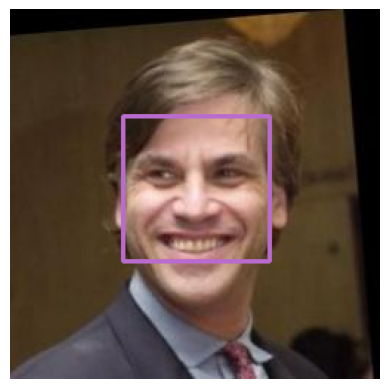

In [11]:
# apply mmod

import dlib
cnn_face_detector = dlib.cnn_face_detection_model_v1("mmod_human_face_detector.dat")
img, label = dataset[10]

img = np.array(img)

gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = cnn_face_detector(gray_image, 1)
print('faces', faces)
for faceRect in faces:
    rect =  faceRect.rect
    x = rect.left()
    y = rect.top()
    w = rect.right() - x
    h = rect.bottom() - y
    print(f"Face coordinates: x={x}, y={y}, w={w}, h={h}")

    # step5: draw rectangle around each face
    cv2.rectangle(img=img, pt1=(x, y), pt2=(x + w, y + h), color=(185, 108, 205), thickness=2)
plt.imshow(img)
plt.axis('off')

## Calculate the time taken for face detection on 1000 samples

### MTCNN

In [12]:
import time

valid_faces=[]

# start measuring the time
start_time = time.time()
for i in range(1000):
    img, label = dataset[i]
    face = mtcnn(img)
    if face is not None:
        valid_faces.append(face)
        
# end measuring the time
end_time = time.time()  
# calculate the time taken for face detection
time_pass = end_time - start_time
print(f"Execution time of MTCNN: {time_pass:.2f} seconds, faces detected: {len(valid_faces)} out of 1000")

Execution time of MTCNN: 40.40 seconds, faces detected: 1000 out of 1000


### MMOD

In [13]:
valid_faces_mmod =[]
# start measuring the time
start_time = time.time()

for i in range(1000):
    img, label = dataset[i]
    img = np.array(img)
    gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = cnn_face_detector(gray_image, 1)  
    
    if faces:
        valid_faces_mmod.append(faces)

# end measuring the time
end_time = time.time()

# calculate the time taken for face detection
time_pass = end_time - start_time
print(f"Execution time of MMOD: {time_pass:.2f} seconds, faces detected: {len(valid_faces_mmod)} out of 1000")

KeyboardInterrupt: 

### Insightface dlib

In [ ]:
valid_faces_dlib = []

# start measuring the time
start_time = time.time()

for i in range(1000):
    img, label = dataset[i]
    img = np.array(img)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = det_model.detect(img_rgb)

    if faces is not None:
        valid_faces_dlib.append(faces)

# end measuring the time
end_time = time.time()

# calculate the time taken for face detection
time_pass = end_time - start_time
print(f"Execution time of det_model (Insightface): {time_pass:.2f} seconds, faces detected: {len(valid_faces_dlib)} out of 1000")

### Haar cascades

In [ ]:
valid_faces_haar = []

# start measuring the time
start_time = time.time()

for i in range(1000):
    img, label = dataset[i]
    img = np.array(img)
    gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces using Haar cascades
    faces = face_cascade.detectMultiScale(
        gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50)
    )

    if len(faces) > 0:
        valid_faces_haar.append(faces)

# end measuring the time
end_time = time.time()

# calculate the time taken for face detection
time_pass = end_time - start_time
print(f"Execution time of Haar cascades: {time_pass:.2f} seconds, faces detected: {len(valid_faces_haar)} out of 1000")

### RetinaFace

In [ ]:
from retinaface import RetinaFace
import numpy as np
import cv2
import time
from PIL import Image
import matplotlib.pyplot as plt

valid_faces_retina_face = []

# start measuring the time
start_time = time.time()

for i in range(1000):
    img, label = dataset[i]
    img = np.array(img)
    rgb_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Detect faces using RetinaFace
    detections = RetinaFace.detect_faces(rgb_image)

    # If faces are detected, process them
    if isinstance(detections, dict):
        for keys in detections.keys():
            face_info = detections[keys]
            facial_area = face_info['facial_area']
            landmarks = face_info['landmarks']

            # Get the eye coordinates
            right_eye = landmarks['right_eye']
            left_eye = landmarks['left_eye']

            # Calculate the angle to rotate the face
            delta_x = left_eye[0] - right_eye[0]
            delta_y = left_eye[1] - right_eye[1]
            angle = np.degrees(np.arctan2(delta_y, delta_x))
            
            img_pil = Image.fromarray(rgb_image)
            center_of_eyes = ((right_eye[0] + left_eye[0]) / 2, (right_eye[1] + left_eye[1]) / 2)

            # Rotate the image to align the face
            aligned_image = img_pil.rotate(angle=angle, center=center_of_eyes)
            aligned_image_np = np.array(aligned_image)
            
            # Display the aligned image
            plt.imshow(cv2.cvtColor(aligned_image_np, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.show()

            # Add the face information to the list
            valid_faces_retina_face.append(facial_area)

            # Draw rectangle and landmarks on the original image
            x1, y1, x2, y2 = facial_area
            cv2.rectangle(rgb_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            for landmark, point in landmarks.items():
                x, y = point
                cv2.circle(img=rgb_image, center=(int(x), int(y)), radius=2, color=(0, 255, 0), thickness=-1)

# end measuring the time
end_time = time.time()

# calculate the time taken for face detection
time_pass = end_time - start_time
print(f"Execution time of RetinaFace: {time_pass:.2f} seconds, faces detected: {len(valid_faces_retina_face)} out of 1000")